# Laboratório — Modulação Digital com Áudio
**Disciplina:** Redes de Computadores — Ciência da Computação  

---

## Índice
- [Setup do Ambiente](#setup)
- [Parâmetros e Bibliotecas](#parametros)
- [Funções Fornecidas](#funcoes)
- [Atividades](#atividades)
    - [Entrega 1 — Relatório de Ruído](#entrega1) *(realizada antes do laboratório)*
    - [Entrega 2 — Sistema de Chat por Áudio](#entrega2) *(apresentada no laboratório)*

---

> ⚠️ **Atenção:** Este notebook **não funciona** em máquinas virtuais (WSL, VirtualBox etc.) por depender de acesso direto ao hardware de áudio.

---
## Setup do Ambiente <a id='setup'></a>

⚠️ Execute a célula abaixo **apenas uma vez** para instalar as dependências necessárias.

In [1]:
!pip install numpy matplotlib soundfile sounddevice scipy

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import sounddevice as sd
from scipy import signal
from scipy.io import wavfile
import time

### Configuração dos Dispositivos de Áudio

Execute a célula abaixo para listar os dispositivos de áudio disponíveis. Identifique o índice correspondente ao seu **microfone** (entrada) e ao seu **alto-falante** (saída) e ajuste as variáveis `input_device` e `output_device` na célula seguinte.

**Exemplo de saída:**
```
   6 Alto-falantes (Realtek), MME (0 in, 2 out)
>  7 Microfone (Realtek), MME (2 in, 0 out)
< 10 Driver de som primário, Windows DirectSound (0 in, 2 out)
```
Neste exemplo, `input_device = 7` e `output_device = 10`.

In [3]:
sd.query_devices()

   0 USB Audio: - (hw:0,0), ALSA (2 in, 2 out)
   1 Dell HR024 Audio Receiver: USB Audio (hw:1,0), ALSA (0 in, 2 out)
   2 HDA Intel PCH: ALC3204 Analog (hw:2,0), ALSA (2 in, 0 out)
   3 HDA Intel PCH: HDMI 0 (hw:2,3), ALSA (0 in, 2 out)
   4 HDA Intel PCH: HDMI 1 (hw:2,7), ALSA (0 in, 8 out)
   5 HDA Intel PCH: HDMI 2 (hw:2,8), ALSA (0 in, 8 out)
   6 HDA Intel PCH: HDMI 3 (hw:2,9), ALSA (0 in, 8 out)
   7 sysdefault, ALSA (128 in, 128 out)
   8 front, ALSA (0 in, 2 out)
   9 surround40, ALSA (0 in, 2 out)
  10 iec958, ALSA (0 in, 2 out)
  11 spdif, ALSA (2 in, 2 out)
  12 samplerate, ALSA (128 in, 128 out)
  13 speexrate, ALSA (128 in, 128 out)
  14 pulse, ALSA (32 in, 32 out)
  15 upmix, ALSA (8 in, 8 out)
  16 vdownmix, ALSA (6 in, 6 out)
  17 dmix, ALSA (0 in, 2 out)
* 18 default, ALSA (32 in, 32 out)

In [4]:
# ✏️ Ajuste os índices conforme os dispositivos listados acima
input_device  = 2   # microfone
output_device = 18   # alto-falante

sd.default.device = (input_device, output_device)
print(f"Entrada : {sd.query_devices(input_device)['name']}")
print(f"Saída   : {sd.query_devices(output_device)['name']}")

Entrada : HDA Intel PCH: ALC3204 Analog (hw:2,0)
Saída   : default


🎯 Execute o código abaixo para validar a configuração: o sistema gravará 3 segundos de áudio e os reproduzirá em seguida. Caso não funcione, ajuste os índices acima.

In [5]:
DURATION    = 3
SAMPLE_RATE = 44100
FILENAME    = "_teste_audio.wav"

print("Gravando 3 segundos — fale ao microfone...")
audio = sd.rec(int(DURATION * SAMPLE_RATE), samplerate=SAMPLE_RATE, channels=1, dtype='float32')
sd.wait()
print("Gravação concluída. Reproduzindo...")

scaled   = audio / (np.max(np.abs(audio)) or 1)
wav_data = np.int16(scaled * 32767)
wavfile.write(FILENAME, SAMPLE_RATE, wav_data)

fs, data = wavfile.read(FILENAME)
sd.play(data, fs)
sd.wait()
os.remove(FILENAME)
print("✅ Se você escutou a gravação, o sistema está configurado corretamente.")

Gravando 3 segundos — fale ao microfone...
Gravação concluída. Reproduzindo...
✅ Se você escutou a gravação, o sistema está configurado corretamente.


---
## Parâmetros Globais <a id='parametros'></a>

Execute esta célula **uma única vez** antes de qualquer atividade. Todos os módulos do notebook dependem destas configurações.

In [6]:
# ── Dispositivos (mantenha os mesmos índices do Setup) ──────────────────
input_device  = 4
output_device = 3
sd.default.device = (input_device, output_device)

# ── Parâmetros de modulação ──────────────────────────────────────────────
SAMPLE_RATE  = 44100   # Hz — taxa de amostragem
BIT_DURATION = 0.5     # segundos por bit (ajustável)
FREQ_LOW     = 440     # Hz — representa bit '0' (nota Lá, A4)
FREQ_HIGH    = 880     # Hz — representa bit '1' (nota Lá, A5)
THRESHOLD    = (FREQ_LOW + FREQ_HIGH) / 2  # limiar de decisão (660 Hz)

print("Parâmetros carregados:")
print(f"  Taxa de amostragem : {SAMPLE_RATE} Hz")
print(f"  Duração por bit    : {BIT_DURATION} s  ({1/BIT_DURATION:.0f} bits/s)")
print(f"  Frequência '0'     : {FREQ_LOW} Hz")
print(f"  Frequência '1'     : {FREQ_HIGH} Hz")
print(f"  Limiar de decisão  : {THRESHOLD} Hz")

Parâmetros carregados:
  Taxa de amostragem : 44100 Hz
  Duração por bit    : 0.5 s  (2 bits/s)
  Frequência '0'     : 440 Hz
  Frequência '1'     : 880 Hz
  Limiar de decisão  : 660.0 Hz


---
## Funções Fornecidas <a id='funcoes'></a>

As funções desta seção compõem a **infraestrutura do laboratório**. Leia os docstrings com atenção — eles descrevem o contrato de cada função e serão necessários para a implementação do NRZI e do Chat.

### Primitivas de Áudio

In [7]:
def generate_tone(frequency: float, duration: float,
                   sample_rate: int = None) -> 'np.ndarray':
    """
    Gera um tom senoidal com janela de Hanning para eliminar cliques nas transições.

    Parâmetros
    ----------
    frequency   : frequência do tom em Hz
    duration    : duração em segundos
    sample_rate : taxa de amostragem em Hz (padrão: SAMPLE_RATE global)

    Retorna
    -------
    np.ndarray : amostras do sinal no intervalo [-1, 1]
    """
    sr     = sample_rate if sample_rate is not None else SAMPLE_RATE
    t      = np.linspace(0, duration, int(sr * duration), endpoint=False)
    tone   = np.sin(2 * np.pi * frequency * t)
    window = np.hanning(len(tone))
    return tone * window


In [8]:
def detect_frequency(segment: 'np.ndarray',
                       sample_rate: int = None) -> float:
    """
    Detecta a frequência dominante em um segmento de áudio via FFT.

    Parâmetros
    ----------
    segment     : trecho do sinal de áudio a analisar
    sample_rate : taxa de amostragem em Hz (padrão: SAMPLE_RATE global)

    Retorna
    -------
    float : frequência dominante em Hz
    """
    sr        = sample_rate if sample_rate is not None else SAMPLE_RATE
    fft       = np.fft.fft(segment)
    freqs     = np.fft.fftfreq(len(fft), 1 / sr)
    magnitude = np.abs(fft[:len(fft) // 2])
    freqs_pos = freqs[:len(freqs) // 2]
    return abs(freqs_pos[np.argmax(magnitude)])


def frequency_to_bit(frequency: float, threshold: float = None) -> str:
    """
    Classifica uma frequência detectada como bit '0' ou '1'.

    Parâmetros
    ----------
    frequency : frequência detectada em Hz
    threshold : limiar de decisão em Hz
                (padrão: THRESHOLD global = média entre FREQ_LOW e FREQ_HIGH)

    Retorna
    -------
    str : '1' se frequency > threshold, '0' caso contrário
    """
    thr = threshold if threshold is not None else THRESHOLD
    return '1' if frequency > thr else '0'


In [9]:
def plot_signal(audio_signal: np.ndarray, title: str, num_bits: int) -> None:
    """
    Exibe o sinal de áudio no domínio do tempo com linhas verticais
    delimitando cada bit transmitido.
    """
    t = np.linspace(0, len(audio_signal) / SAMPLE_RATE, len(audio_signal))
    plt.figure(figsize=(14, 3))
    plt.plot(t, audio_signal, linewidth=0.6)
    plt.title(title, fontsize=13)
    plt.xlabel('Tempo (s)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    for i in range(1, num_bits):
        plt.axvline(x=i * BIT_DURATION, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    plt.tight_layout()
    plt.show()

In [10]:
def adicionar_ruido(audio_signal: np.ndarray, snr_db: float) -> np.ndarray:
    """
    Adiciona ruído gaussiano branco ao sinal com uma relação sinal-ruído (SNR) definida.

    Parâmetros
    ----------
    audio_signal : sinal original
    snr_db       : SNR desejado em dB.
                   Valores altos (ex: 30 dB) → pouco ruído.
                   Valores baixos ou negativos (ex: 0 dB, -5 dB) → muito ruído.

    Retorna
    -------
    np.ndarray : sinal corrompido

    Exemplos
    --------
    sinal_limpo  = encode_nrz("10110")
    sinal_ruido  = adicionar_ruido(sinal_limpo, snr_db=10)   # leve
    sinal_ruido2 = adicionar_ruido(sinal_limpo, snr_db=-5)   # severo
    """
    signal_power = np.mean(audio_signal ** 2)
    snr_linear   = 10 ** (snr_db / 10)
    noise_power  = signal_power / snr_linear
    noise        = np.random.normal(0, np.sqrt(noise_power), len(audio_signal))
    return audio_signal + noise

In [11]:
def text_to_bits(text: str) -> str:
    """
    Converte uma string de texto em uma sequência de bits (ASCII, 8 bits por caractere).

    Exemplo
    -------
    text_to_bits("Hi")  →  '0100100001101001'
    """
    return ''.join(format(ord(c), '08b') for c in text)


def bits_to_text(bits: str) -> str:
    """
    Converte uma sequência de bits de volta para texto (ASCII, 8 bits por caractere).
    Ignora caracteres não imprimíveis resultantes de erros de decodificação.

    Exemplo
    -------
    bits_to_text('0100100001101001')  →  'Hi'
    """
    chars = []
    for i in range(0, len(bits) - 7, 8):
        byte = bits[i:i+8]
        if len(byte) == 8:
            try:
                chars.append(chr(int(byte, 2)))
            except ValueError:
                chars.append('?')
    return ''.join(chars)

### Codificadores e Decodificadores Fornecidos

As implementações de **NRZ** e **Manchester** são fornecidas como referência. Analise-as com atenção antes de implementar o NRZI.

In [12]:
# ── NRZ ─────────────────────────────────────────────────────────────────

def encode_nrz(data_bits: str,
               bit_duration: float = None,
               freq_low: float = None,
               freq_high: float = None,
               sample_rate: int = None) -> 'np.ndarray':
    """
    Codifica uma sequência de bits usando NRZ (Non-Return-to-Zero).

    Regra de codificação:
        '1'  →  freq_high durante bit_duration segundos
        '0'  →  freq_low  durante bit_duration segundos

    Parâmetros
    ----------
    data_bits    : sequência de bits (ex: "10110")
    bit_duration : duração de cada bit em segundos (padrão: BIT_DURATION global)
    freq_low     : frequência para '0' em Hz       (padrão: FREQ_LOW global)
    freq_high    : frequência para '1' em Hz       (padrão: FREQ_HIGH global)
    sample_rate  : taxa de amostragem em Hz        (padrão: SAMPLE_RATE global)

    Retorna
    -------
    np.ndarray : sinal de áudio codificado
    """
    bd = bit_duration if bit_duration is not None else BIT_DURATION
    fl = freq_low     if freq_low     is not None else FREQ_LOW
    fh = freq_high    if freq_high    is not None else FREQ_HIGH
    sr = sample_rate  if sample_rate  is not None else SAMPLE_RATE

    segments = []
    for bit in data_bits:
        freq = fh if bit == '1' else fl
        segments.append(generate_tone(freq, bd, sr))
    return np.concatenate(segments)


def decode_nrz(audio_signal: 'np.ndarray', num_bits: int,
               bit_duration: float = None,
               freq_low: float = None,
               freq_high: float = None,
               sample_rate: int = None) -> str:
    """
    Decodifica um sinal NRZ recuperando os bits transmitidos.

    Estratégia: analisa a região central de cada janela de bit
    (descartando 25% das bordas) para evitar artefatos de transição.

    Parâmetros
    ----------
    audio_signal : sinal de áudio recebido
    num_bits     : número esperado de bits
    bit_duration : duração de cada bit em segundos (padrão: BIT_DURATION global)
    freq_low     : frequência para '0' em Hz       (padrão: FREQ_LOW global)
    freq_high    : frequência para '1' em Hz       (padrão: FREQ_HIGH global)
    sample_rate  : taxa de amostragem em Hz        (padrão: SAMPLE_RATE global)

    Retorna
    -------
    str : bits decodificados
    """
    bd  = bit_duration if bit_duration is not None else BIT_DURATION
    fl  = freq_low     if freq_low     is not None else FREQ_LOW
    fh  = freq_high    if freq_high    is not None else FREQ_HIGH
    sr  = sample_rate  if sample_rate  is not None else SAMPLE_RATE
    thr = (fl + fh) / 2

    spb  = int(sr * bd)
    bits = []
    for i in range(num_bits):
        s, e = i * spb, (i + 1) * spb
        if e > len(audio_signal):
            break
        centro = audio_signal[s + spb // 4 : e - spb // 4]
        freq   = detect_frequency(centro, sr)
        bits.append(frequency_to_bit(freq, thr))
    return ''.join(bits)


In [13]:
# ── Manchester ───────────────────────────────────────────────────────────

def encode_manchester(data_bits: str,
                       bit_duration: float = None,
                       freq_low: float = None,
                       freq_high: float = None,
                       sample_rate: int = None) -> 'np.ndarray':
    """
    Codifica uma sequência de bits usando Manchester.

    Regra de codificação (IEEE 802.3):
        '1'  →  freq_high (1ª metade) → freq_low  (2ª metade)
        '0'  →  freq_low  (1ª metade) → freq_high (2ª metade)

    Parâmetros
    ----------
    data_bits    : sequência de bits (ex: "10110")
    bit_duration : duração total de cada bit em segundos (padrão: BIT_DURATION global)
    freq_low     : frequência para '0' em Hz             (padrão: FREQ_LOW global)
    freq_high    : frequência para '1' em Hz             (padrão: FREQ_HIGH global)
    sample_rate  : taxa de amostragem em Hz              (padrão: SAMPLE_RATE global)

    Retorna
    -------
    np.ndarray : sinal de áudio codificado
    """
    bd   = bit_duration if bit_duration is not None else BIT_DURATION
    fl   = freq_low     if freq_low     is not None else FREQ_LOW
    fh   = freq_high    if freq_high    is not None else FREQ_HIGH
    sr   = sample_rate  if sample_rate  is not None else SAMPLE_RATE
    half = bd / 2

    segments = []
    for bit in data_bits:
        if bit == '1':
            segments += [generate_tone(fh, half, sr), generate_tone(fl, half, sr)]
        else:
            segments += [generate_tone(fl, half, sr), generate_tone(fh, half, sr)]
    return np.concatenate(segments)


def decode_manchester(audio_signal: 'np.ndarray', num_bits: int,
                       bit_duration: float = None,
                       freq_low: float = None,
                       freq_high: float = None,
                       sample_rate: int = None) -> str:
    """
    Decodifica um sinal Manchester analisando a transição no centro de cada bit.

    Regra de decisão:
        freq_high → freq_low  ⟹  '1'
        freq_low  → freq_high ⟹  '0'
        Outra transição        ⟹  '?' (erro de sincronização)

    Parâmetros
    ----------
    audio_signal : sinal de áudio recebido
    num_bits     : número esperado de bits
    bit_duration : duração total de cada bit em segundos (padrão: BIT_DURATION global)
    freq_low     : frequência para '0' em Hz             (padrão: FREQ_LOW global)
    freq_high    : frequência para '1' em Hz             (padrão: FREQ_HIGH global)
    sample_rate  : taxa de amostragem em Hz              (padrão: SAMPLE_RATE global)

    Retorna
    -------
    str : bits decodificados ('?' indica erro de transição)
    """
    bd  = bit_duration if bit_duration is not None else BIT_DURATION
    fl  = freq_low     if freq_low     is not None else FREQ_LOW
    fh  = freq_high    if freq_high    is not None else FREQ_HIGH
    sr  = sample_rate  if sample_rate  is not None else SAMPLE_RATE
    thr = (fl + fh) / 2

    spb  = int(sr * bd)
    bits = []
    for i in range(num_bits):
        s, e = i * spb, (i + 1) * spb
        if e > len(audio_signal):
            break
        mid  = s + spb // 2
        pad  = spb // 8
        f1   = detect_frequency(audio_signal[s + pad : mid - pad], sr)
        f2   = detect_frequency(audio_signal[mid + pad : e - pad], sr)
        b1   = frequency_to_bit(f1, thr)
        b2   = frequency_to_bit(f2, thr)
        if   b1 == '1' and b2 == '0': bits.append('1')
        elif b1 == '0' and b2 == '1': bits.append('0')
        else:                          bits.append('?')
    return ''.join(bits)


---
## Entrega 1 — Relatório de Ruído <a id='entrega1'></a>

> 📅 **Esta entrega deve ser realizada antes do dia do laboratório.**

### Contexto

Todo canal de comunicação real está sujeito a ruído. A **relação sinal-ruído** (SNR — *Signal-to-Noise Ratio*) quantifica a intensidade do sinal útil em relação ao ruído presente no canal, expressa em decibéis (dB):

$$\text{SNR}_{\text{dB}} = 10 \cdot \log_{10}\!\left(\frac{P_{\text{sinal}}}{P_{\text{ruído}}}\right)$$

- **SNR alto (ex: 30 dB)** → sinal muito mais potente que o ruído → comunicação confiável  
- **SNR baixo (ex: 0 dB)** → sinal e ruído com potências iguais → erros frequentes  
- **SNR negativo (ex: −10 dB)** → ruído supera o sinal → comunicação degradada

A métrica utilizada para avaliar a qualidade da decodificação é a **Taxa de Erro de Bit** (BER — *Bit Error Rate*):

$$\text{BER} = \frac{\text{número de bits incorretos}}{\text{número total de bits}}$$

### Objetivo

Caracterizar o comportamento das modulações **NRZ**, **Manchester** e **NRZI** (implementada por vocês) sob diferentes níveis de ruído, produzindo gráficos de **SNR × BER** e um relatório analítico.

### Tarefa 1.1 — Implementação do NRZI

O **NRZI** (*Non-Return-to-Zero Inverted*) difere do NRZ na forma como codifica os bits:

| Bit | Ação no NRZI |
|:---:|:--------------|
| `'1'` | **Inverte** a frequência atual (se estava em FREQ_LOW, vai para FREQ_HIGH, e vice-versa) |
| `'0'` | **Mantém** a frequência atual |

O estado inicial (antes do primeiro bit) é `FREQ_LOW`.

**Implemente** as funções `encode_nrzi` e `decode_nrzi` abaixo.

In [14]:
def encode_nrzi(data_bits: str,
                bit_duration: float = None,
                freq_low: float = None,
                freq_high: float = None,
                sample_rate: int = None) -> 'np.ndarray':
    """
    Codifica uma sequência de bits usando NRZI.

    Regra de codificação:
        '1'  →  inverte a frequência atual
        '0'  →  mantém a frequência atual

    Estado inicial: freq_low

    Parâmetros
    ----------
    data_bits    : sequência de bits (ex: "10110")
    bit_duration : duração de cada bit em segundos (padrão: BIT_DURATION global)
    freq_low     : frequência para estado baixo em Hz (padrão: FREQ_LOW global)
    freq_high    : frequência para estado alto em Hz  (padrão: FREQ_HIGH global)
    sample_rate  : taxa de amostragem em Hz           (padrão: SAMPLE_RATE global)

    Retorna
    -------
    np.ndarray : sinal de áudio codificado

    Dica
    ----
    Mantenha uma variável `freq_atual` iniciada em freq_low.
    Para cada bit, decida se inverte ou mantém, gere o tom
    com generate_tone(freq_atual, bd, sr) e concatene.
    """
    bd = bit_duration if bit_duration is not None else BIT_DURATION
    fl = freq_low     if freq_low     is not None else FREQ_LOW
    fh = freq_high    if freq_high    is not None else FREQ_HIGH
    sr = sample_rate  if sample_rate  is not None else SAMPLE_RATE

    # ✏️ Implemente aqui
    segments = []
    freq_atual = fl
    for bit in data_bits:
        if bit == '1':
            freq_atual = fh if freq_atual == fl else fl
        segments.append(generate_tone(freq_atual, bd, sr))
    return np.concatenate(segments)


def decode_nrzi(audio_signal: 'np.ndarray', num_bits: int,
                bit_duration: float = None,
                freq_low: float = None,
                freq_high: float = None,
                sample_rate: int = None) -> str:
    """
    Decodifica um sinal NRZI recuperando os bits originais.

    Parâmetros
    ----------
    audio_signal : sinal de áudio recebido
    num_bits     : número esperado de bits
    bit_duration : duração de cada bit em segundos (padrão: BIT_DURATION global)
    freq_low     : frequência para estado baixo em Hz (padrão: FREQ_LOW global)
    freq_high    : frequência para estado alto em Hz  (padrão: FREQ_HIGH global)
    sample_rate  : taxa de amostragem em Hz           (padrão: SAMPLE_RATE global)

    Retorna
    -------
    str : bits decodificados

    Dica
    ----
    Detecte a frequência de cada janela de bit com detect_frequency().
    Compare com a janela anterior: mudança de estado → '1', sem mudança → '0'.
    Para o primeiro bit, compare com o estado inicial (freq_low).
    """
    bd  = bit_duration if bit_duration is not None else BIT_DURATION
    fl  = freq_low     if freq_low     is not None else FREQ_LOW
    fh  = freq_high    if freq_high    is not None else FREQ_HIGH
    sr  = sample_rate  if sample_rate  is not None else SAMPLE_RATE
    thr = (fl + fh) / 2

    # ✏️ Implemente aqui
    estado_anterior = '0' if fl < thr else '1'
    spb = int(sr * bd)
    bits = []
    for i in range(num_bits):
        s, e = i * spb, (i + 1) * spb
        if e > len(audio_signal):
            break

        centro = audio_signal[s + spb // 4 : e - spb // 4]
        freq_atual = detect_frequency(centro, sr)
        estado_atual = '1' if freq_atual > thr else '0'

        bit = '0'
        if estado_atual != estado_anterior:
            bit = '1'
        bits.append(bit)
        estado_anterior = estado_atual
    return ''.join(bits)



**Validação:** execute a célula abaixo para verificar a implementação. A saída esperada é `True` nas três linhas.

In [15]:
# Validação: todos os casos devem retornar True
params = dict(
    bit_duration = BIT_DURATION,
    freq_low     = FREQ_LOW,
    freq_high    = FREQ_HIGH,
    sample_rate  = SAMPLE_RATE,
)

#utilizem menssagens maiores no relatorio
for seq in ["10110", "00000", "11111", "10101010"]:
    sinal   = encode_nrzi(seq, **params)
    decoded = decode_nrzi(sinal, len(seq), **params)
    ok      = seq == decoded
    print(f"  {seq}  →  {decoded}  |  correto: {ok}")


  10110  →  10110  |  correto: True
  00000  →  00000  |  correto: True
  11111  →  11111  |  correto: True
  10101010  →  10101010  |  correto: True


### Tarefa 1.2 — Análise de Robustez ao Ruído

Nesta tarefa você irá conduzir **dois conjuntos de experimentos** e comparar os resultados entre si.

**Experimento A — Configuração padrão**  
Utilize os parâmetros globais já definidos no notebook (`BIT_DURATION = 0.5`, `FREQ_LOW = 440`, `FREQ_HIGH = 880`).

**Experimento B — Variação de parâmetros**  
Repita o experimento alterando ao menos **dois** dos parâmetros da tabela abaixo. Documente os valores escolhidos e justifique a escolha na análise.

| Parâmetro | Descrição | Sugestões |
|:----------|:----------|:----------|
| `BIT_DURATION` | Duração de cada bit em segundos | 0.1 s, 0.25 s, 1.0 s, 2.0 s |
| `FREQ_LOW` / `FREQ_HIGH` | Frequências de '0' e '1' | Aproximar (440/550 Hz) ou afastar (300/1200 Hz) |
| `SAMPLE_RATE` | Taxa de amostragem | 22050 Hz, 8000 Hz |

> Para cada experimento, execute as células de infraestrutura, experimento e gráfico em sequência. As questões Q1.1, Q1.2 e Q1.3 devem ser respondidas para **ambos** os experimentos.

In [16]:
def calcular_ber(original: str, decodificado: str) -> float:
    """
    Calcula a Taxa de Erro de Bit (BER) entre dois strings de bits.

    Retorna
    -------
    float : proporção de bits incorretos (0.0 = perfeito, 1.0 = tudo errado)
    """
    total_bits = max(len(original), len(decodificado))
    if total_bits == 0:
        return 0.0
    bits_incorretos = 0
    for i in range(total_bits):
        o = original[i] if i < len(original) else None
        d = decodificado[i] if i < len(decodificado) else None
        if o != d:
            bits_incorretos += 1
    return bits_incorretos / total_bits



def experimento_ruido(bits_originais: str, snr_range,
                      bit_duration: float = None,
                      freq_low: float = None,
                      freq_high: float = None,
                      sample_rate: int = None,
                      n_trials: int = 10) -> dict:
    """
    Para cada valor de SNR, realiza n_trials codificações com ruído e
    retorna a BER média de cada modulação.

    Parâmetros
    ----------
    bits_originais : str   — sequência de bits de referência
    snr_range      : array — valores de SNR (dB) a testar
    bit_duration   : duração de cada bit em segundos (padrão: BIT_DURATION global)
    freq_low       : frequência para '0' em Hz       (padrão: FREQ_LOW global)
    freq_high      : frequência para '1' em Hz       (padrão: FREQ_HIGH global)
    sample_rate    : taxa de amostragem em Hz        (padrão: SAMPLE_RATE global)
    n_trials       : repetições por nível de SNR

    Retorna
    -------
    dict : {'NRZ': [...], 'Manchester': [...], 'NRZI': [...]}
    """
    # Resolve parâmetros — usa os globais como fallback
    params = dict(
        bit_duration = bit_duration if bit_duration is not None else BIT_DURATION,
        freq_low     = freq_low     if freq_low     is not None else FREQ_LOW,
        freq_high    = freq_high    if freq_high    is not None else FREQ_HIGH,
        sample_rate  = sample_rate  if sample_rate  is not None else SAMPLE_RATE,
    )

    resultados = {'NRZ': [], 'Manchester': [], 'NRZI': []}
    nb_bits    = len(bits_originais)

    for snr in snr_range:
        bers = {'NRZ': [], 'Manchester': [], 'NRZI': []}
        for _ in range(n_trials):
            # NRZ
            sig = adicionar_ruido(encode_nrz(bits_originais, **params), snr)
            bers['NRZ'].append(calcular_ber(bits_originais, decode_nrz(sig, nb_bits, **params)))
            # Manchester
            sig = adicionar_ruido(encode_manchester(bits_originais, **params), snr)
            bers['Manchester'].append(calcular_ber(bits_originais, decode_manchester(sig, nb_bits, **params)))
            # NRZI
            try:
                sig = adicionar_ruido(encode_nrzi(bits_originais, **params), snr)
                bers['NRZI'].append(calcular_ber(bits_originais, decode_nrzi(sig, nb_bits, **params)))
            except NotImplementedError:
                bers['NRZI'].append(float('nan'))
        for mod in resultados:
            resultados[mod].append(float(np.nanmean(bers[mod])))

    return resultados


---
#### Q1.1 — Curva SNR × BER

Execute as duas células abaixo para rodar o experimento e gerar o gráfico. O gráfico deve exibir as três modulações (NRZ, Manchester e NRZI) na mesma figura, com cores distintas e legenda identificada.

O eixo x representa o SNR em dB em ordem **decrescente** (canal progressivamente pior da esquerda para a direita). O eixo y representa a BER. O objetivo é observar em que ponto cada modulação começa a degradar e com que velocidade a taxa de erro cresce à medida que o canal piora.

**Repita para cada configuração do Experimento B**, alterando os parâmetros na célula de configuração antes de executar.

In [17]:
# ── EXPERIMENTO A — Configuração padrão ─────────────────────────────────
# Não altere estes valores no Experimento A.
# Para o Experimento B, duplique este bloco e modifique os parâmetros.

params_A = dict(
    bit_duration = 0.5,
    freq_low     = 440,
    freq_high    = 880,
    sample_rate  = 44100,
)

bits_teste = "1010100000001111110000010101010111000"
snr_vals   = np.arange(30, -21, -2)   # 30 dB até -20 dB, passo de 2 dB

print(f"Configuração A: {params_A}")
print(f"Executando experimento com {len(snr_vals)} níveis de SNR...")
resultados_A = experimento_ruido(bits_teste, snr_vals, **params_A, n_trials=15)
print("Concluído.")


Configuração A: {'bit_duration': 0.5, 'freq_low': 440, 'freq_high': 880, 'sample_rate': 44100}
Executando experimento com 26 níveis de SNR...
Concluído.


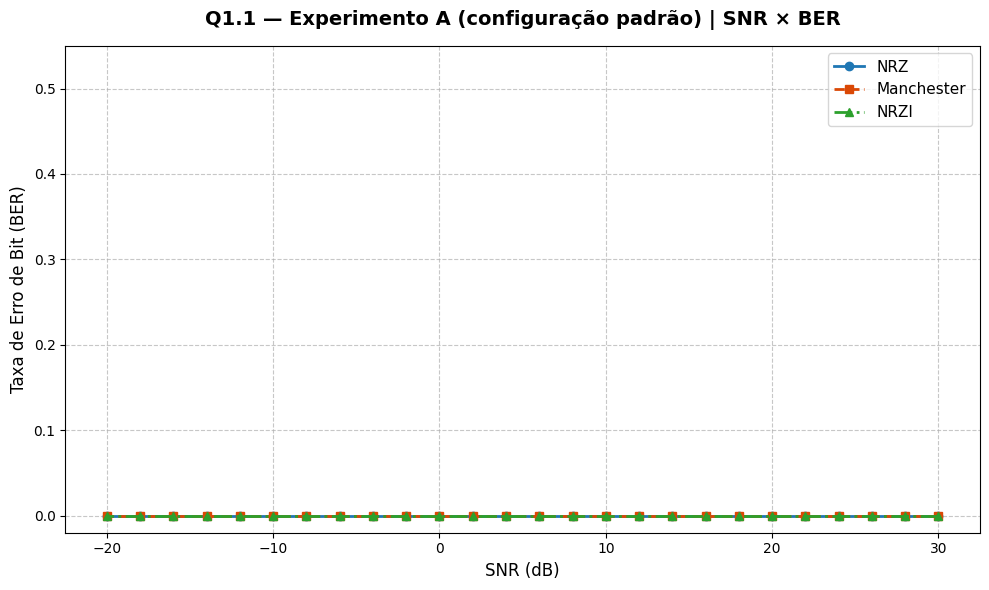

In [18]:
def plot_snr_ber(resultados, snr_vals, titulo, filename):
    """
    Gera e salva o gráfico SNR x BER para as três modulações.
    """
    plt.figure(figsize=(10, 6))
    
    estilos = {
        'NRZ': {'marker': 'o', 'color': '#1f77b4', 'linestyle': '-'},
        'Manchester': {'marker': 's', 'color': "#da4805", 'linestyle': '--'},
        'NRZI': {'marker': '^', 'color': '#2ca02c', 'linestyle': '-.'}
    }
    
    for mod, ber_list in resultados.items():
        if mod in estilos:
            plt.plot(snr_vals, ber_list, label=mod, linewidth=2, **estilos[mod])
        else:
            plt.plot(snr_vals, ber_list, label=mod, marker='x', linewidth=2)
            
    plt.title(titulo, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('SNR (dB)', fontsize=12)
    plt.ylabel('Taxa de Erro de Bit (BER)', fontsize=12)
    
    plt.ylim(-0.02, 0.55)
    
    plt.grid(True, which="both", linestyle="--", alpha=0.7)
    
    plt.legend(fontsize=11, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300)


plot_snr_ber(
    resultados_A, snr_vals,
    titulo="Q1.1 — Experimento A (configuração padrão) | SNR × BER",
    filename="q11_experimento_A.png"
)

---
#### Q1.2 — Pontos Críticos de Degradação

Com base no gráfico de Q1.1, identifique para cada modulação os dois limiares abaixo. O objetivo é compreender a **faixa operacional** de cada esquema de codificação — ou seja, em que condições de canal cada modulação ainda é utilizável e a partir de quando a comunicação se torna inviável.

- **SNR de primeiro erro (BER > 0):** ponto em que o canal começa a introduzir erros. A comunicação ainda é possível, mas deixa de ser perfeita.
- **SNR de falha total (BER ≥ 0,5):** ponto em que a decodificação equivale a um chute aleatório. A comunicação torna-se completamente inviável.

A diferença entre esses dois valores define a **margem de degradação** de cada modulação: uma margem larga indica deterioração gradual; uma margem estreita indica colapso abrupto.

Preencha a tabela abaixo para o **Experimento A** e repita para cada configuração do **Experimento B**.

In [19]:
def pontos_criticos(resultados, snr_vals, label=""):
    """
    Calcula e exibe os pontos críticos de degradação (SNR de primeiro erro
    e SNR de falha total) para cada modulação.
    """
    print(f"{'─'*60}")
    print(f"  Pontos Críticos — {label}")
    print(f"{'─'*60}")
    print(f"  {'Modulação':<14} {'1º erro (BER>0)':<22} {'Falha total (BER≥0.5)'}")
    print(f"{'─'*60}")
    for mod, bers in resultados.items():
        primeiro_erro  = next((snr_vals[i] for i, b in enumerate(bers) if b > 0),   None)
        falha_total    = next((snr_vals[i] for i, b in enumerate(bers) if b >= 0.5), None)
        pe_str = f"{primeiro_erro} dB" if primeiro_erro is not None else "não atingido"
        ft_str = f"{falha_total} dB"  if falha_total  is not None else "não atingido"
        print(f"  {mod:<14} {pe_str:<22} {ft_str}")
    print(f"{'─'*60}")

pontos_criticos(resultados_A, snr_vals, label="Experimento A (configuração padrão)")

────────────────────────────────────────────────────────────
  Pontos Críticos — Experimento A (configuração padrão)
────────────────────────────────────────────────────────────
  Modulação      1º erro (BER>0)        Falha total (BER≥0.5)
────────────────────────────────────────────────────────────
  NRZ            não atingido           não atingido
  Manchester     não atingido           não atingido
  NRZI           não atingido           não atingido
────────────────────────────────────────────────────────────


Complemente a saída acima preenchendo a tabela abaixo com os valores identificados. Repita uma tabela para cada configuração do Experimento B.

**Experimento A — Configuração padrão** (`BIT_DURATION=0.5`, `FREQ_LOW=440`, `FREQ_HIGH=880`)

| Modulação | SNR de primeiro erro — BER > 0 (dB) | SNR de falha total — BER ≥ 0,5 (dB) | Margem de degradação (dB) |
|:---------:|:-----------------------------------:|:------------------------------------:|:-------------------------:|
| NRZ        | não atingido | não atingido | - |
| Manchester | não atingido | não atingido | - |
| NRZI       | não atingido | não atingido | - |

---
#### Experimento B — Variação de Parâmetros

Altere ao menos **dois** parâmetros na célula abaixo e execute novamente o experimento. Repita quantas vezes julgar necessário para cobrir as combinações que você irá discutir em Q1.3.

In [26]:
# ── EXPERIMENTO B —  Altere os parâmetros abaixo ──────────────────────

params_B = dict(
    bit_duration = 0.1,    #  ex: 0.1, 0.25, 1.0, 2.0
    freq_low     = 300,    #  ex: 440, 300
    freq_high    = 1200,    #  ex: 550 (aproximado), 1200 (afastado)
    sample_rate  = 8000,  #  ex: 22050, 8000
)

# Etiqueta automática para títulos e tabelas
label_B = (
    f"bit_duration={params_B['bit_duration']}s | "
    f"freq={params_B['freq_low']}/{params_B['freq_high']}Hz | "
    f"sr={params_B['sample_rate']}Hz"
)

print(f"Configuração B: {label_B}")
print(f"Executando experimento...")
resultados_B = experimento_ruido(bits_teste, snr_vals, **params_B, n_trials=15)
print("Concluído.")


Configuração B: bit_duration=0.1s | freq=300/1200Hz | sr=8000Hz
Executando experimento...
Concluído.


────────────────────────────────────────────────────────────
  Pontos Críticos — Experimento B — bit_duration=0.1s | freq=300/1200Hz | sr=8000Hz
────────────────────────────────────────────────────────────
  Modulação      1º erro (BER>0)        Falha total (BER≥0.5)
────────────────────────────────────────────────────────────
  NRZ            -14 dB                 não atingido
  Manchester     -10 dB                 -16 dB
  NRZI           -12 dB                 não atingido
────────────────────────────────────────────────────────────


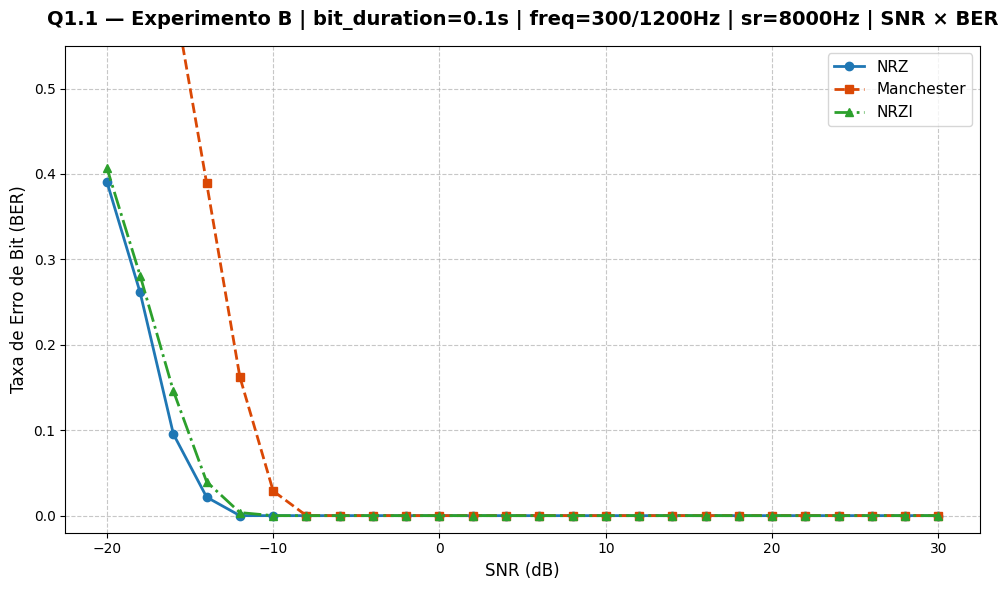

In [27]:
plot_snr_ber(
    resultados_B, snr_vals,
    titulo=f"Q1.1 — Experimento B | {label_B} | SNR × BER",
    filename="q11_experimento_B.png"
)
pontos_criticos(resultados_B, snr_vals, label=f"Experimento B — {label_B}")

**Experimento B** — *(preencha o cabeçalho com os parâmetros utilizados)*

| Modulação | SNR de primeiro erro — BER > 0 (dB) | SNR de falha total — BER ≥ 0,5 (dB) | Margem de degradação (dB) |
|:---------:|:-----------------------------------:|:------------------------------------:|:-------------------------:|
| NRZ        | -14 dB | não atingido | - |
| Manchester | -10 dB | -16 dB | 6 dB |
| NRZI       | -12 dB | não atingido | - |

---
#### Q1.3 — Análise Comparativa *(mínimo 15 linhas)*

Com base nos gráficos e tabelas de Q1.1 e Q1.2, redija uma análise comparando o comportamento das três modulações nos dois experimentos. Sua análise deve abordar:

- Qual modulação apresentou maior robustez ao ruído e por quê?
- Como a variação de `BIT_DURATION` afetou os resultados — taxas mais lentas tornam o sistema mais robusto?
- O afastamento ou aproximação de `FREQ_LOW`/`FREQ_HIGH` impactou a capacidade de decodificação? Como?
- Os resultados obtidos confirmam o comportamento esperado pela teoria vista em sala?
- Relacione ao menos um dos resultados com uma situação real de transmissão (modem, rádio, USB etc.).

> ⚠️ **A escrita desta análise deve ser de autoria própria do grupo. O uso de LLMs ou ferramentas de geração de texto é vedado e poderá resultar em anulação da entrega.**

*(escreva aqui)*

---
## Entrega 2 — Sistema de Chat por Áudio <a id='entrega2'></a>

> 📅 **Esta entrega é apresentada no dia do laboratório.**

### Descrição

O grupo deverá construir um **sistema de chat por áudio** funcional utilizando as modulações estudadas. O sistema deve ser capaz de:

1. **Transmitir** uma mensagem de texto digitada pelo usuário, convertendo-a em sinal de áudio;
2. **Receber** um sinal de áudio pelo microfone e exibir a mensagem decodificada;
3. Suportar as três modulações: **NRZ**, **Manchester** e **NRZI** — selecionáveis em tempo de execução.

### Critérios de Avaliação (aplicados pelo professor no laboratório)

| Critério | Peso |
|:---------|:----:|
| Sistema transmite e decodifica com NRZ | 25% |
| Sistema transmite e decodifica com Manchester | 25% |
| Sistema transmite e decodifica com NRZI | 25% |
| Qualidade do código (legibilidade, organização) | 15% |
| Documentação (docstrings e comentários) | 10% |

### Dinâmica do Laboratório

Durante a aula, cada grupo transmitirá uma **mensagem secreta** (fornecida pelo professor) para a turma. Os demais grupos tentarão decodificá-la com seus próprios sistemas e registrarão o resultado em formulário disponibilizado no momento da aula. Os dados coletados serão analisados coletivamente para ilustrar o impacto de distância e ruído ambiente na comunicação real.

---

### Tarefa 2.1 — Implementação do Chat

In [ ]:
# ── TRANSMISSOR ──────────────────────────────────────────────────────────
#
# Complete a função abaixo. Ela deve:
#   1. Converter a mensagem em bits com text_to_bits()
#   2. Codificar com a modulação escolhida, passando os parâmetros
#      bit_duration, freq_low, freq_high e sample_rate explicitamente
#   3. Reproduzir o sinal com sd.play() / sd.wait()
#   4. Exibir: mensagem, bits, modulação e duração estimada
# ─────────────────────────────────────────────────────────────────────────

def transmitir(mensagem: str, modulacao: str = 'NRZ',
               bit_duration: float = None,
               freq_low: float = None,
               freq_high: float = None,
               sample_rate: int = None) -> None:
    """
    Transmite uma mensagem de texto como sinal de áudio FSK.

    Parâmetros
    ----------
    mensagem     : texto a transmitir
    modulacao    : 'NRZ', 'NRZI' ou 'MANCHESTER'
    bit_duration : duração de cada bit em segundos (padrão: BIT_DURATION global)
    freq_low     : frequência para '0' em Hz       (padrão: FREQ_LOW global)
    freq_high    : frequência para '1' em Hz       (padrão: FREQ_HIGH global)
    sample_rate  : taxa de amostragem em Hz        (padrão: SAMPLE_RATE global)
    """
    # ✏️ Implemente aqui
    raise NotImplementedError("transmitir() não implementado.")


In [ ]:
# ── RECEPTOR ─────────────────────────────────────────────────────────────
#
# Complete a função abaixo. Ela deve:
#   1. Calcular a duração da captura:
#      num_chars * 8 bits * bit_duration + margem de segurança
#   2. Capturar o áudio com sd.rec() / sd.wait()
#   3. Decodificar com a modulação escolhida, passando os parâmetros
#      bit_duration, freq_low, freq_high e sample_rate explicitamente
#   4. Converter os bits para texto com bits_to_text()
#   5. Exibir a mensagem recebida
# ─────────────────────────────────────────────────────────────────────────

def receber(num_chars: int, modulacao: str = 'NRZ',
            bit_duration: float = None,
            freq_low: float = None,
            freq_high: float = None,
            sample_rate: int = None) -> str:
    """
    Captura áudio pelo microfone e decodifica a mensagem recebida.

    Parâmetros
    ----------
    num_chars    : número de caracteres esperados na mensagem
    modulacao    : 'NRZ', 'NRZI' ou 'MANCHESTER'
    bit_duration : duração de cada bit em segundos (padrão: BIT_DURATION global)
    freq_low     : frequência para '0' em Hz       (padrão: FREQ_LOW global)
    freq_high    : frequência para '1' em Hz       (padrão: FREQ_HIGH global)
    sample_rate  : taxa de amostragem em Hz        (padrão: SAMPLE_RATE global)

    Retorna
    -------
    str : mensagem decodificada
    """
    # ✏️ Implemente aqui
    raise NotImplementedError("receber() não implementado.")


### Tarefa 2.2 — Teste do Sistema

Utilize as células abaixo para validar o sistema antes do laboratório. Teste as três modulações e verifique se a mensagem é recuperada corretamente.

In [ ]:
# ── TESTE DE TRANSMISSÃO ─────────────────────────────────────────────────
# Escolha a modulação, a mensagem e os parâmetros, depois execute.
# Os parâmetros omitidos usarão os valores globais definidos na célula de configuração.

MODULACAO = 'NRZ'     # 'NRZ' | 'NRZI' | 'MANCHESTER'
MENSAGEM  = 'REDES'   # ✏️ altere para testar

transmitir(
    MENSAGEM, MODULACAO,
    bit_duration = BIT_DURATION,
    freq_low     = FREQ_LOW,
    freq_high    = FREQ_HIGH,
    sample_rate  = SAMPLE_RATE,
)


In [ ]:
# ── TESTE DE RECEPÇÃO ────────────────────────────────────────────────────
# Execute esta célula ANTES de reproduzir o áudio no dispositivo transmissor.
# Os parâmetros devem coincidir com os utilizados na transmissão.

MODULACAO  = 'NRZ'          # deve coincidir com o transmissor
NUM_CHARS  = len(MENSAGEM)

msg_recebida = receber(
    NUM_CHARS, MODULACAO,
    bit_duration = BIT_DURATION,
    freq_low     = FREQ_LOW,
    freq_high    = FREQ_HIGH,
    sample_rate  = SAMPLE_RATE,
)
print(f"\nMensagem recebida: {msg_recebida}")


### Questões para o Relatório da Entrega 2 *(preencha abaixo)*

---

**Q2.1** — Qual modulação apresentou melhor desempenho durante os testes? Justifique com base nos resultados da Entrega 1.

*(escreva aqui)*

---

**Q2.2** — O que ocorre com a decodificação quando a taxa de bits (`1/BIT_DURATION`) é aumentada? Explique o fenômeno observado.

*(escreva aqui)*

---

**Q2.3** — Durante o laboratório, sua equipe conseguiu decodificar a mensagem dos outros grupos? Descreva as condições (distância, ruído ambiente) e os resultados obtidos.

*(escreva aqui)*